In [103]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [104]:
from sklearn.datasets import load_iris

In [105]:
dataset = load_iris(return_X_y = False, as_frame = False)

dataset.feature_names

['sepal length (cm)',
 'sepal width (cm)',
 'petal length (cm)',
 'petal width (cm)']

In [106]:
df = pd.DataFrame(dataset.data, columns=dataset.feature_names)
df["target"] = dataset.target

df.head(), df.shape

(   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
 0                5.1               3.5                1.4               0.2   
 1                4.9               3.0                1.4               0.2   
 2                4.7               3.2                1.3               0.2   
 3                4.6               3.1                1.5               0.2   
 4                5.0               3.6                1.4               0.2   
 
    target  
 0       0  
 1       0  
 2       0  
 3       0  
 4       0  ,
 (150, 5))

In [107]:
df['target'].unique()

array([0, 1, 2])

In [108]:
df['petal length (cm)'].describe()

count    150.000000
mean       3.758000
std        1.765298
min        1.000000
25%        1.600000
50%        4.350000
75%        5.100000
max        6.900000
Name: petal length (cm), dtype: float64

150 rader av data. 4 features, 3 target värden.

sepal length range 4.3 - 7.9. mean = 5.843333. std = 0.828066

sepal width range 2.0 - 4.4. mean = 3.057333. std = 0.435866

petal length range 1.0 - 6.9. mean = 3.758000. std = 1.765298 

petal width range 0.1 - 2.5. mean = 1.199333. std = 0.762238 

In [109]:
df['target'].value_counts()

target
0    50
1    50
2    50
Name: count, dtype: int64

equally devided dataset.

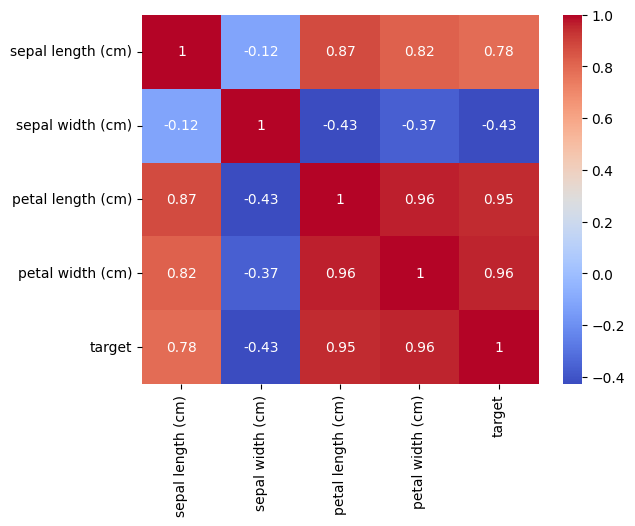

In [110]:
corr = df.corr('pearson')

sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.show()

all features correlate significantly. sepal width has a negative correlation with the other features, meaning as the other features increase, sepal width decreases.

In [111]:
setosa = df[df['target'] == 0]
versicolor = df[df['target'] == 1]
virginica = df[df['target'] == 2]

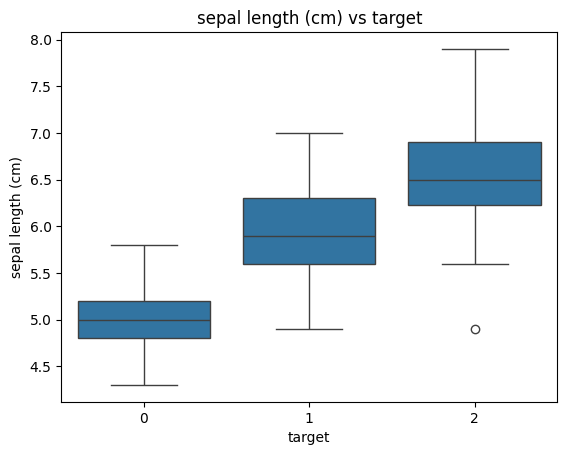

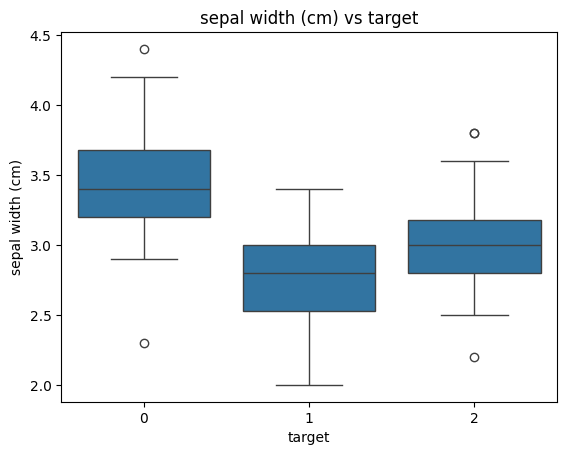

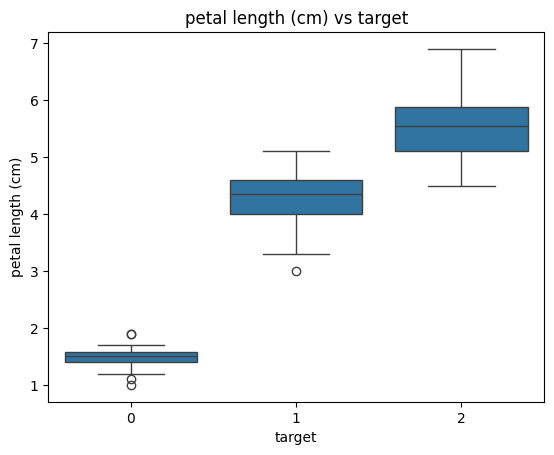

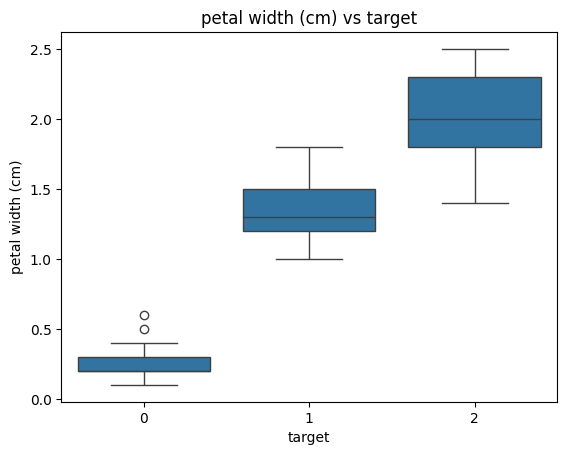

In [112]:
features = df.drop("target", axis=1).columns
for feature in features:
    sns.boxplot(x="target", y=feature, data=df)
    plt.title(f"{feature} vs target")
    plt.show()

In [113]:
species = [setosa, versicolor, virginica]
df_cleaned = []
df_outliers = []
for specie in species:
    Q1 = df.quantile(0.25)
    Q3 = df.quantile(0.75)
    IQR = Q3 - Q1
    lower_outlier = Q1 - 1.5 * IQR
    upper_outlier = Q3 + 1.5 * IQR

    outlier_mask = (specie < lower_outlier) | (specie > upper_outlier)

    specie_cleaned = specie[~outlier_mask.any(axis=1)]
    specie_outliers = specie[outlier_mask.any(axis=1)]

    df_cleaned.append(specie_cleaned)
    df_outliers.append(specie_outliers.index)


In [114]:
print(f"Outlier rows are: {df_outliers}")

Outlier rows are: [Index([15, 32, 33], dtype='int64'), RangeIndex(start=60, stop=61, step=1), RangeIndex(start=0, stop=0, step=1)]


In [115]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [117]:
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df)
X_train, X_test, y_train, y_test = train_test_split(df_scaled, df["target"], test_size=0.33, random_state = 42)
print(X_train.mean(), X_test.mean(), y_train.mean(), y_test.mean())
print(X_train.std(), X_test.std(), y_train.std(), y_test.std())

-0.009078602999362516 0.018157205998723894 1.03 0.94
0.9850015068955612 1.0291013247646836 0.8097262288308102 0.8429781995389676


In [129]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay


In [119]:
logreg = LogisticRegression()

param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['lbfgs', 'saga'],
    'max_iter': [100, 200, 500, 1000]
}

kfold = KFold(n_splits=5, shuffle=True, random_state=42)

grid = GridSearchCV(
    logreg,
    param_grid,
    cv=kfold,
    scoring='accuracy',
    n_jobs=-1
)

grid.fit(X_train, y_train)


c:\Users\vilma\Machine-learning\ML_venv\Lib\site-packages\sklearn\model_selection\_validation.py:490: FitFailedWarning: 
100 fits failed out of a total of 400.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
100 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\vilma\Machine-learning\ML_venv\Lib\site-packages\sklearn\model_selection\_validation.py", line 833, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\vilma\Machine-learning\ML_venv\Lib\site-packages\sklearn\base.py", line 1336, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "c:\Users\vilma\Machine-learning\ML_venv\Lib\site-packages\sklea

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegression()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.01, 0.1, ...], 'max_iter': [100, 200, ...], 'penalty': ['l1', 'l2'], 'solver': ['lbfgs', 'saga']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",KFold(n_split... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and p

In [125]:
print(grid.best_params_)

{'C': 0.1, 'max_iter': 100, 'penalty': 'l1', 'solver': 'saga'}


C: 0.1,  max_iter: 100,  penalty: l1,  solver: saga

In [121]:
best_model = grid.best_estimator_
print(best_model)

LogisticRegression(C=0.1, penalty='l1', solver='saga')


In [128]:
print(best_model.coef_.shape)
print(best_model.intercept_)

(3, 5)
[-0.21655991  0.51530615 -0.29874624]


In [126]:
print(grid.best_score_)

1.0


In [127]:
y_pred = best_model.predict(X_test)

print("Test Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


Test Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      1.00      1.00        15
           2       1.00      1.00      1.00        16

    accuracy                           1.00        50
   macro avg       1.00      1.00      1.00        50
weighted avg       1.00      1.00      1.00        50



[[19  0  0]
 [ 0 15  0]
 [ 0  0 16]]


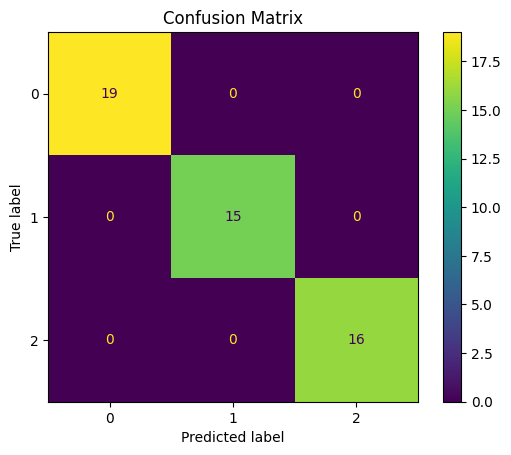

In [131]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix")
plt.show()

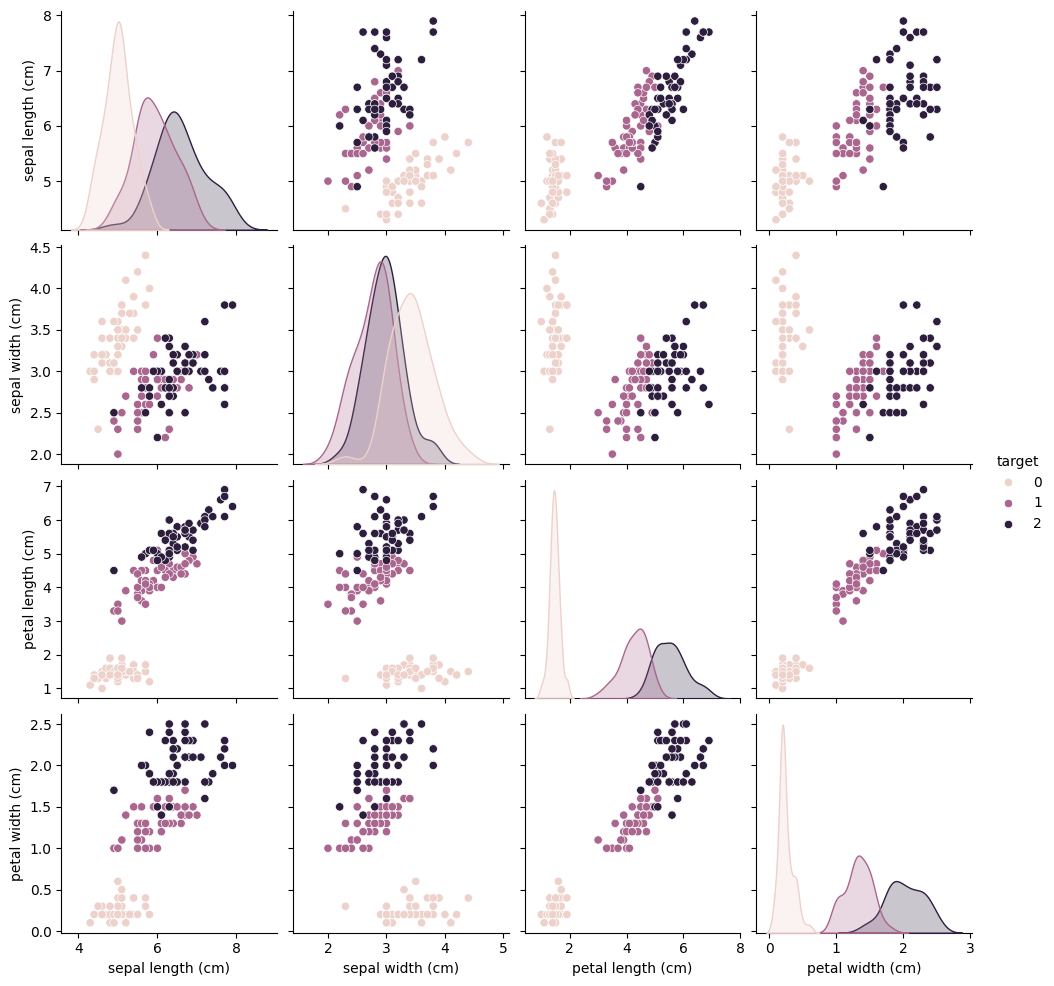

In [132]:
sns.pairplot(df, hue="target")
plt.show()

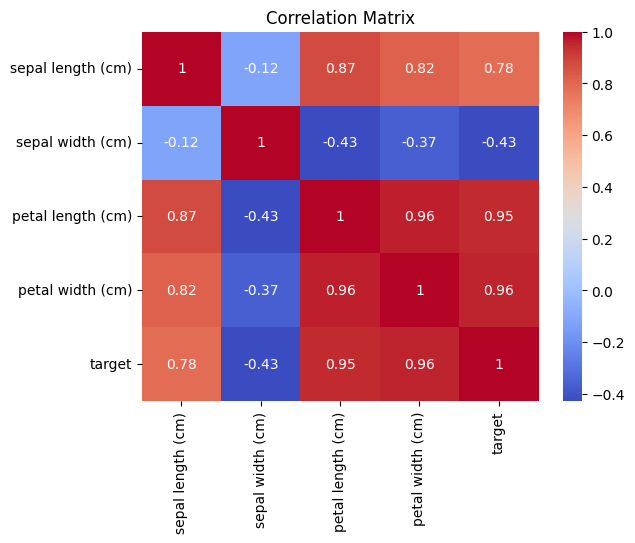

In [133]:
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()